<a href="https://colab.research.google.com/github/Teyoltlahui23/Stats-21/blob/main/Geog_191_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style = 'ticks',font_scale=1.75)
from scipy import stats

from google.colab import drive
drive.mount('/content/drive') # connect to your google drive
df = pd.read_csv('/content/drive/MyDrive/GEOG191_Data/US-MMS_short.csv')

df['Date'] = [datetime.datetime(df['YEAR'].iloc[i],df['MONTH'].iloc[i],df['DAY'].iloc[i],
                       df['HOUR'].iloc[i]) for i in range(len(df))]
#Why do we need to put this?

# df = pd.read_csv('../Data/US-MMS_short.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Time series visualization**

In [26]:
df.head()

,YEAR,MONTH,DAY,HOUR,TA,PA,P,WS,RH,SWC,...,LE,H,NEE,GPP,USTAR,SW_NET,LW_NET,LAI,GA,Date
0,2003,1,1,1,2.002,97.4,0.1,4.24,83.63,47.0,...,3.321300,-39.9312,0.662678,0.0,0.668,0.419,1.4,0.489881,5.539262,2003-01-01 01:00:00
1,2003,1,1,2,1.205,97.3,0.8,4.63,91.97,47.0,...,5.979780,-66.9933,1.156150,0.0,0.688,0.927,1.8,0.489860,5.492919,2003-01-01 02:00:00
2,2003,1,1,3,0.836,97.2,0.7,5.45,92.56,47.0,...,-4.503500,-71.0931,0.567972,0.0,0.848,0.910,3.2,0.489840,7.289668,2003-01-01 03:00:00
3,2003,1,1,4,0.632,97.2,0.8,5.21,92.76,48.0,...,0.394589,-75.0968,0.443852,0.0,0.793,1.036,2.6,0.489819,6.646328,2003-01-01 04:00:00
4,2003,1,1,5,0.326,97.1,0.9,5.02,95.70,49.0,...,-1.880010,-51.4169,0.500611,0.0,0.785,0.393,2.0,0.489799,6.811513,2003-01-01 05:00:00


## a) Plot out the time series of hourly, daily, and monthly average air temperature. Calculate the mean and standard deviation at each time scale.

/tmp/ipykernel_1424/1844022705.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M',on='Date').mean()
/tmp/ipykernel_1424/1844022705.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H', on= 'Date').mean()


12.395734340390339
10.783044913823254
12.395618083868174
10.37886306075379
12.336283719254748
9.313287394019403


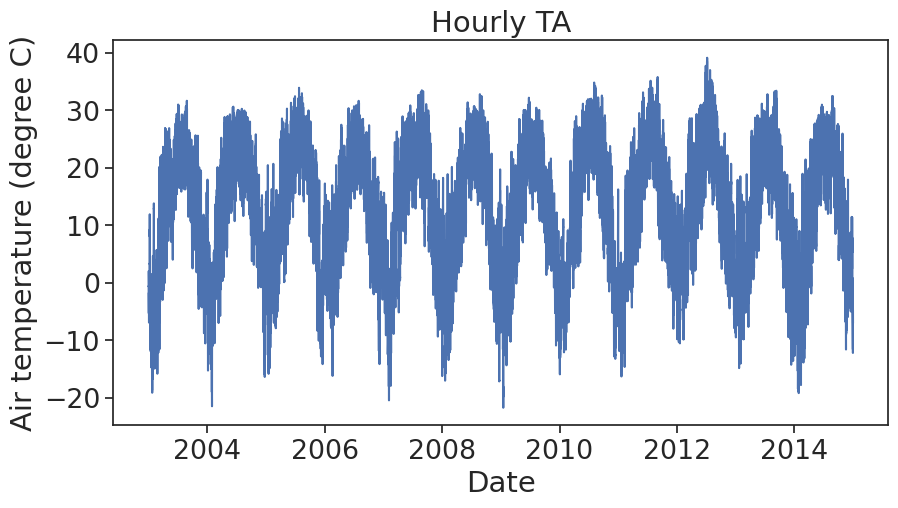

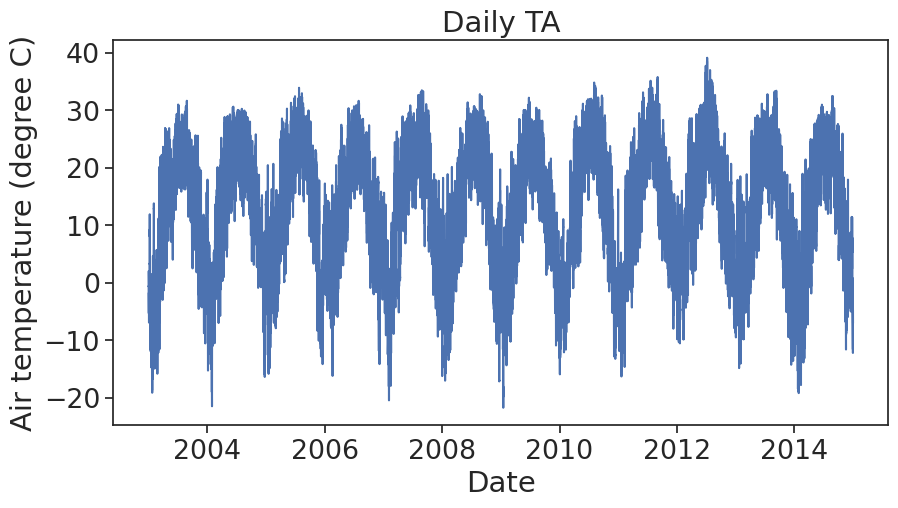

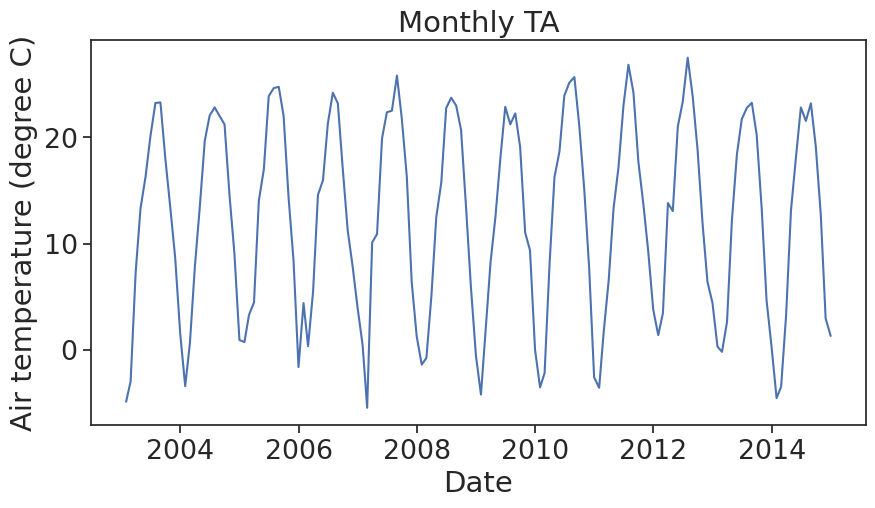

In [27]:
tt = [datetime.datetime(df['YEAR'].iloc[i],df['MONTH'].iloc[i],df['DAY'].iloc[i],
                       df['HOUR'].iloc[i]) for i in range(len(df))]
df['Date'] = tt

df_daily = df.resample('D',on='Date').mean()
df_monthly = df.resample('M',on='Date').mean()
df_hourly = df.resample('H', on= 'Date').mean()

#.mean() already calculates the average

#df_monthly.head()

plt.figure(figsize=(10,5))
plt.plot(df_hourly['TA'])
#plt.plot(df['Date'],df['TA'])
plt.xlabel('Date')
plt.ylabel('Air temperature (degree C)')
plt.title('Hourly TA')

plt.figure(figsize=(10,5))
plt.plot(df_hourly['TA'])
plt.xlabel('Date')
plt.ylabel('Air temperature (degree C)')
plt.title('Daily TA')

plt.figure(figsize=(10,5))
plt.plot(df_monthly['TA'])
plt.xlabel('Date')
plt.ylabel('Air temperature (degree C)')
plt.title('Monthly TA')

hourly_mean = df_hourly['TA'].mean()
hourly_std= df_hourly['TA'].std()
print(hourly_mean)
print(hourly_std)

daily_mean = df_daily['TA'].mean()
daily_std = df_daily['TA'].std()
print(daily_mean)
print(daily_std)

monthly_mean = df_monthly['TA'].mean()
monthly_std = df_monthly['TA'].std()
print(monthly_mean)
print(monthly_std)




### Answer:
The hourly average air temperature mean is 12.396°C. The hourly average air temperature standard deviation is 10.783.

The daily average air temperature mean is 12.396°C. The daily average air temperature standard deviation is 10.379.

The monthly average air temperature mean is 12.336°C. The monthly average air temperature standard deviation is 9.313.

## b) Comparing the results across time scales, what patterns remain consistent, and what differences emerge? Can you provide an intuitive explanation for why?

### Answer:

The hourly and daily average air temperature mean remains relatively constant but decreases when looking at it on a monthly scale.

The hourly, daily, and monthly standard deviation, on the other hand, show a steady decrease the more larger the time scale becomes. In this sense, the hourly shows the highest standard deviation, meaning that it falls farther from the average while the monthly standard deviation shows a smaller deviation from the mean.

An explanation for this can be because at a smaller time scale, there is more deviation because you are recording more samples, where each sample give give data that can deviate from the average. However, on a larger scale, the averages will be more general and will not demonstrate a lot of the smaller deviations, however the averages will be less specific and less accurate to each date and hour.

In [28]:
# df_daily = df.resample('D',on='Date').mean()
# print(df_daily)

# df_monthly = df.resample('M',on='Date').mean()
# print(df_monthly)

# **2. Probabilities**

## a) What is the probability that the daily mean air temperature is below 0 °C?

In [29]:
#print(len(df_daily['TA']<0))
#should be 662 but getting 4383?, difference is that I put df_daily[] another time
print(df_daily['TA'][df_daily['TA']<0])

number_of_freezing_days = len(df_daily[df_daily['TA']<0])
print(number_of_freezing_days)
probability_of_freezing_days = number_of_freezing_days/len(df_daily)
print(probability_of_freezing_days)

Date
2003-01-02   -1.876292
2003-01-03   -3.957750
2003-01-04   -2.677708
2003-01-06   -0.870292
2003-01-07   -0.867125
                ...   
2014-12-21   -0.467583
2014-12-28   -0.846083
2014-12-29   -2.411625
2014-12-30   -3.716875
2014-12-31   -8.463917
Name: TA, Length: 662, dtype: float64
662
0.15103810175678758


### Answer:
The probability that the daily mean air temperature is below 0 °C is 15%.

## b) Given that the daily mean air temperature is below 0 °C, what is the probability that daily precipitation exceeds 0 mm/hr?

In [30]:
freezing_days = df_daily[df_daily['TA']<0]

rainy_days = df_daily[df_daily['P']>0]
#daily precipitation

freezing_and_rainy = df_daily[(df_daily['TA']<0) & (df_daily['P']>0)]
print(len(freezing_and_rainy)/len(freezing_days))

0.19788519637462235


### Answer:
There is a 19.8%  probability that the daily precipitation exceeds 0 mm/hr given that the daily mean air temperature is below 0 °C.

## c) What is the probability of a day experiencing both a daily mean air temperature below 0 °C and precipitation exceeding 0 mm/hr?

In [31]:
print(len(freezing_and_rainy)/len(df_daily))

0.029888204426192107


### Answer:
There is a 2.98% probability that the daily mean air temperature is below 0 °C and that the daily precipitation exceeds 0 mm/hr.

### d) Identify the statistical terms for the probabilities calculated in parts (a), (b), and (c).
Hint: Consider marginal, conditional, and joint probabilities.

### Answer:

For part A, I calculated the marginal probability because the probability that the daily mean air temperatue is below 0°C is not dependent on any other variable

For part B, I calculated the conditional probability because the probability that the number of days that the daily precipitation exceeds 0 mm/hr was based on the daily mean air temperature is below 0°C.

For part C, I calculated the join probability because while the two probabilities of experiences a daily mean air temperature below 0°C and the number of days that the daily precipitation exceeds 0 mm/hr were not dependent on each other. Instead, the probability was based on the number of days they would occur at the same time in comparison to any other day.

# **3. Distributions**

Filter the historical dataset to include only observations from the month of April across
all available years.

## a) Using the empirical data, determine the probability that the daily mean air temperature in April exceeds 20 °C.

In [32]:
df_april = df_daily[df_daily['MONTH']==4]
days_over_20 = len(df_april[df_april['TA']>20])
print(days_over_20)

probability_days_over_20 = days_over_20/len(df_april)
print(probability_days_over_20)
#len(df_daily[df_daily['TA']<0])


43
0.11944444444444445


### Answer:
There is an 11.94% probability that the daily mean air temperature in April exceeds 20 °C

## b) Select a suitable theoretical distribution and estimate its parameters using the historical April data. Provide the distribution name and the fitted parameter values, and include a visualization comparing the fitted Probability Density Function (PDF) against the empirical distribution.

### Answer:
A suitable theoretical distribution for this graph is the Gaussian distribution and its parameters are mean(mu) = 13.27°C, standard deviation(sigma) = 5.60°C, and variance (sigma^2) = 31.33°C^2.

13.270944675925925 5.59738740946423
[-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7
   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25
  26  27  28  29]


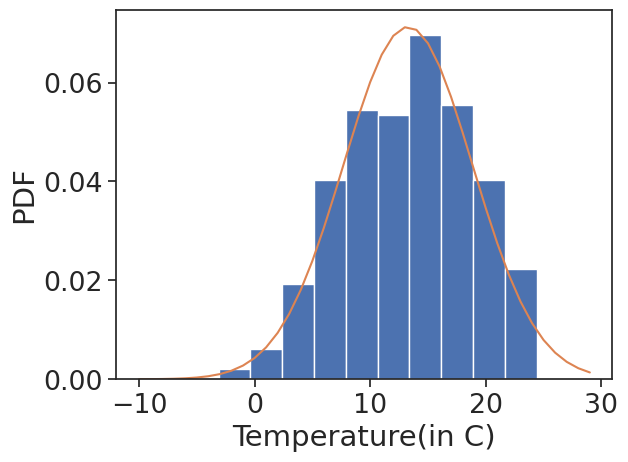

In [33]:
plt.figure()
plt.hist(df_april['TA'],density =True)
#This makes the histogram

mu, sigma = stats.norm.fit(df_april['TA'])
print(mu,sigma)
#mu = mean
#sigma = standard deviation

ta_range = np.arange(-10, 30, 1)
print(ta_range)
pdf = stats.norm.pdf(ta_range,mu,sigma)
plt.xlabel('Temperature(in C)'); plt.ylabel('PDF')

plt.plot(ta_range,pdf)
#This makes the line



# **4. Hypothesis Testing**

In addition to the April dataset from Problem 3, do the same to create an additional
dataset containing only October observations for all years.

## a) Generate histograms for daily air temperatures in April and October. Calculate and compare the mean and standard deviation for both months.

13.270944675925925
5.6051777923705925
13.414193548387097
5.1101830726337045


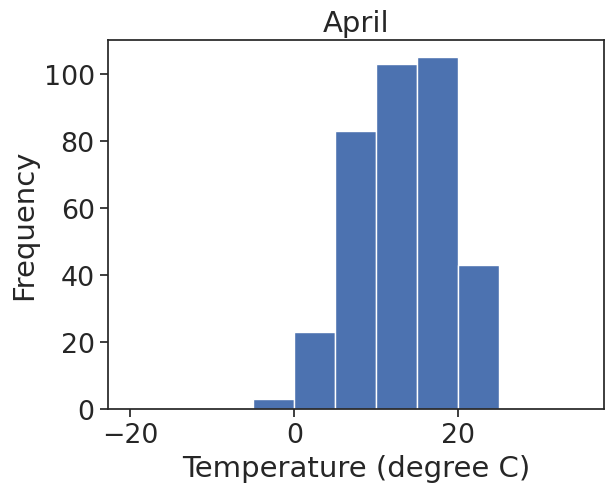

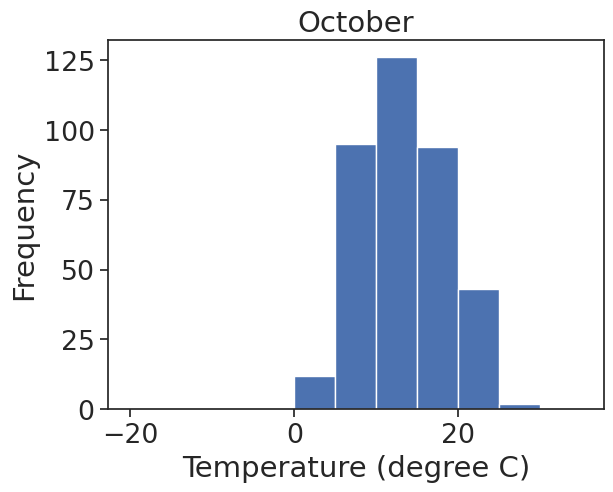

In [34]:
# plt.figure()
# plt.hist(df_april['TA'],density=True)

# plt.figure()
# plt.hist(df_october['TA'],density=True)

df_october = df_daily[df_daily['MONTH']==10]

plt.figure()
plt.hist(df_april['TA'],bins=np.arange(-20,40,5))
plt.xlabel('Temperature (degree C)'); plt.ylabel('Frequency')
plt.title('April')

april_ta_mean = df_april['TA'].mean()
april_ta_std = df_april['TA'].std()

plt.figure()
plt.hist(df_october['TA'],bins=np.arange(-20,40,5))
plt.xlabel('Temperature (degree C)'); plt.ylabel('Frequency')
plt.title('October')

october_ta_mean = df_october['TA'].mean()
october_ta_std = df_october['TA'].std()

print(april_ta_mean)
print(april_ta_std)
print(october_ta_mean)
print(october_ta_std)

#FOR DENSITY
# plt.figure()
# plt.hist(df_daily['TA'],bins=np.arange(-20,40,5),density=True)
# plt.xlabel('Temperature (degree C)'); plt.ylabel('PDF')

# You can pull out the hight of the PDF bars using the following code (in the variable hist)
# hist,bins = np.histogram(df_daily['TA'],bins=np.arange(-20,40,5),density=True)

### Answer:
The April mean of daily air temperatures is 13.27°C while the standard deviation for April is 5.61°C.

On the other hand, the October mean of daily air temperatures is 13.41°C while the standard deviation is 5.11°C

The mean air temperature is slightly higher in October than in April while April has a higher standard deviation.

## b) Use a two-sided z-test to determine if the mean daily temperatures of the two months differ significantly. State the null and alternative hypotheses, and report the resulting z-statistic and p-value. Conclude whether to reject or accept the null hypothesis based on these results.

z-statistic: 0.360986329025878
z-test p-value (two-sided): 0.7181096668542915
z-test p-value (one-sided): 0.3590548334271457


Text(0, 0.5, 'Probability Density Function')

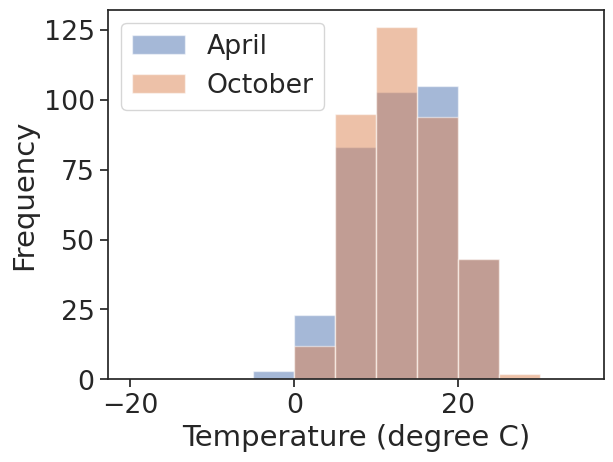

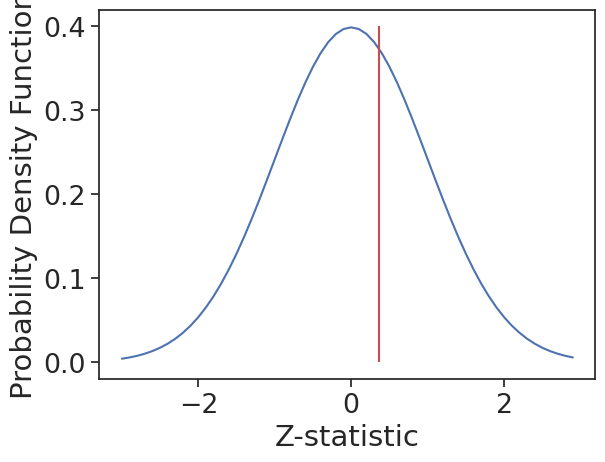

In [35]:
plt.figure()
plt.hist(df_april['TA'],bins=np.arange(-20,40,5),label='April',alpha=0.5)
#plt.hist(df_october['TA'],bins=np.arange(-20,40,5))
plt.hist(df_october['TA'],bins=np.arange(-20,40,5), label='October',alpha=0.5)
#plt.hist(df_october['TA'],bins=np.arange(50,100,2), label='October',alpha=0.5)
plt.xlabel('Temperature (degree C)')
plt.ylabel('Frequency')
plt.legend()

#april_ta_mean)
#october_ta_mean
#df_october = df_daily[df_daily['MONTH']==10]

april_daily_temp = df_april['TA']
october_daily_temp = df_october['TA']

SE = np.sqrt(april_daily_temp.var()/len(april_daily_temp)+october_daily_temp.var()/len(october_daily_temp))

z_stat = (october_ta_mean-april_ta_mean)/SE
z_cdf = stats.norm.cdf(z_stat,0,1)
ztest_p_value = min(z_cdf,(1-z_cdf))*2
print('z-statistic:', z_stat)
print('z-test p-value (two-sided):', ztest_p_value)
print('z-test p-value (one-sided):', ztest_p_value/2)

zrange = np.arange(-3,3,0.1)
plt.figure()
plt.plot(zrange,stats.norm.pdf(zrange,0,1))
plt.vlines(z_stat,0,0.4,color='r',label='z-statistic')
plt.xlabel('Z-statistic')
plt.ylabel('Probability Density Function')

### Answer:

H0: The mean daily temperatures of the two months are the same

H1: The mean daily temperatures of the two months are different

The mean daily temperatures difference result in a z-statistic of 0.36 and a p-value(two-sided) of 0.72. Due to the p-value being over 0.05, it is not statistically significant and we fail to reject the null hypothesis that the mean daily temperatures of both months are the same.

## c) Re-evaluate the comparison by performing a two-sided t-test and compare your findings to the z-test results.

In [36]:
t_stat, ttest_p_value = stats.ttest_ind(april_daily_temp, october_daily_temp, equal_var=False)
print('t-statistic:', t_stat)
print('t-test p-value (two-sided):', ttest_p_value)
print('t-test p-value (one-sided):', ttest_p_value/2)

t-statistic: -0.360986329025878
t-test p-value (two-sided): 0.7182157351614207
t-test p-value (one-sided): 0.35910786758071034


### Answer:
The t-statistic is -0.36 while the z-statistic is 0.36, showing only a difference in the sign of the value. The t-test p-value for two-sided is slightly higher but still remains about the same with a difference of about 0.0001.

# **5. Bonus**

Repeat Problem 4 but compare the daily temperatures for April and November.

## a) Generate histograms for daily air temperatures in April and November. Calculate and compare the mean and standard deviation for both months.

April TA mean = 13.270944675925925
April TA std = 5.6051777923705925
November TA mean = 7.263538425925925
November TA mean = 5.793637504787319


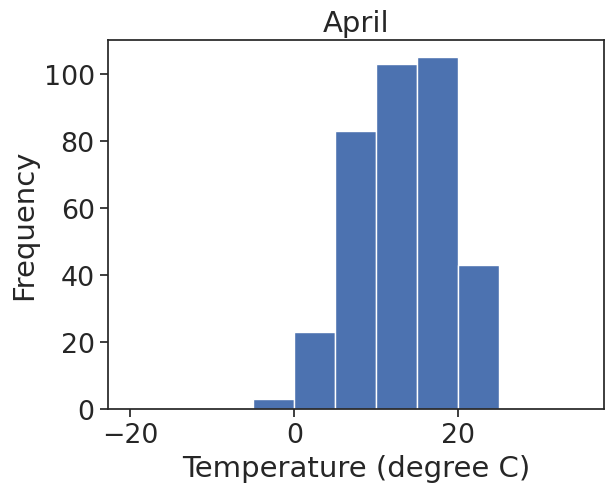

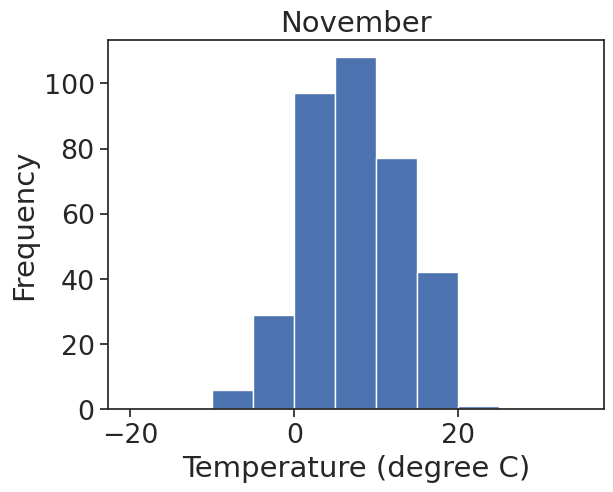

In [37]:
df_november = df_daily[df_daily['MONTH']==11]

plt.figure()
plt.hist(df_april['TA'],bins=np.arange(-20,40,5))
plt.xlabel('Temperature (degree C)'); plt.ylabel('Frequency')
plt.title('April')

april_ta_mean = df_april['TA'].mean()
april_ta_std = df_april['TA'].std()

plt.figure()
plt.hist(df_november['TA'],bins=np.arange(-20,40,5))
plt.xlabel('Temperature (degree C)'); plt.ylabel('Frequency')
plt.title('November')

november_ta_mean = df_november['TA'].mean()
november_ta_std = df_november['TA'].std()

print("April TA mean =", april_ta_mean)
print("April TA std =",april_ta_std)
print("November TA mean =",november_ta_mean)
print("November TA mean =",november_ta_std)

### Answer:

For April, the mean is 13.27°C and it's standard deviation is 5.6°C.

For November, the mean is 7.26°C and its standard deviation is 5.79°C.

For these two months, April has a much higher mean temperature than Novemeber and their standard deviation between the days are about the same, meaning they both deviate from the average by around 5.6(for April) and 5.79(for November).

## b) Use a two-sided z-test to determine if the mean daily temperatures of the two months differ significantly. State the null and alternative hypotheses, and report the resulting z-statistic and p-value. Conclude whether to reject or accept the null hypothesis based on these results.

z-statistic: -14.139504316691289
z-test p-value (two-sided): 2.1680610908053193e-45
z-test p-value (one-sided): 1.0840305454026597e-45


Text(0, 0.5, 'Probability Density Function')

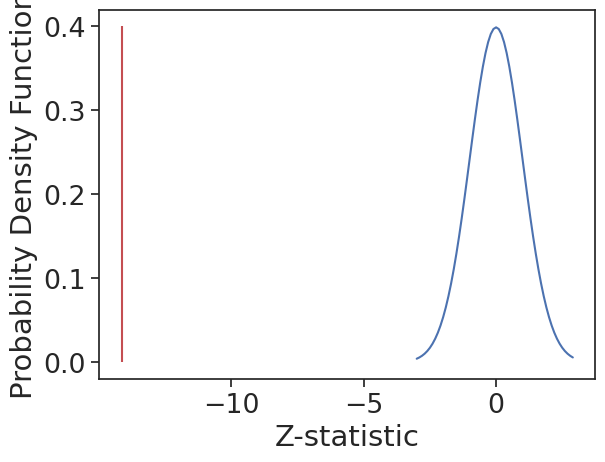

In [38]:
april_daily_temp = df_april['TA']
november_daily_temp = df_november['TA']

SE = np.sqrt(april_daily_temp.var()/len(april_daily_temp)+november_daily_temp.var()/len(november_daily_temp))

z_stat = (november_ta_mean-april_ta_mean)/SE
z_cdf = stats.norm.cdf(z_stat,0,1)
ztest_p_value = min(z_cdf,(1-z_cdf))*2
print('z-statistic:', z_stat)
print('z-test p-value (two-sided):', ztest_p_value)
print('z-test p-value (one-sided):', ztest_p_value/2)

zrange = np.arange(-3,3,0.1)
plt.figure()
plt.plot(zrange,stats.norm.pdf(zrange,0,1))
plt.vlines(z_stat,0,0.4,color='r',label='z-statistic')
plt.xlabel('Z-statistic')
plt.ylabel('Probability Density Function')

### Answer:
H0: The mean daily temperatures of the two months are the same

H1: The mean daily temperatures of the two months are different

The mean daily temperatures difference result in a z-statistic of -14.14 and a p-value(two-sided) of 2.17e-45, a very small number. Due to the p-value being much under 0.05, this test is statistically significant and we reject the null hypothesis that the mean daily temperatures of both months are the same.

## c) Re-evaluate the comparison by performing a two-sided t-test and compare your findings to the z-test results.

In [39]:
t_stat, ttest_p_value = stats.ttest_ind(april_daily_temp, november_daily_temp, equal_var=False)
print('t-statistic:', t_stat)
print('t-test p-value (two-sided):', ttest_p_value)
print('t-test p-value (one-sided):', ttest_p_value/2)

t-statistic: 14.139504316691292
t-test p-value (two-sided): 3.222134539346326e-40
t-test p-value (one-sided): 1.611067269673163e-40


### Answer:
The t-statistic is 12.14 while the z-statistic is -12.14, showing only a difference in the sign of the value. The t-test p-value for two-sided is slightly larger by 5 decimal spaces but still remains about the same because it is still a small enough p-value to reject the null hypothesis.